## A notebook for testing the seir equations with a forward Euler and a Monte Carlo model.

In [1]:
import time
import pandas as pd
import numpy as np
from IPython.display import HTML
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.animation import FuncAnimation

import monte_carlo.seir_monte_carlo as mc
import forward_euler.seir_forward_euler as f

### Input Parameters

In [2]:
seir_labels = ["Susceptible", "Exposed", "Infected", "Recovered"]

shared_parameters = {
    "s_0": 0.95,
    "e_0": 0.05,
    "i_0": 0.0,
    "r_0": 0.0,
    "beta": 1.0,
    "sigma": 0.1,
    "gamma": 0.005
}

# Forward Euler parameters
step = 0.1
t_final = 100
f_euler_output = "f_euler_seir_data.csv"

# Monte Carlo parameters
length = 100
agent_count = 250
MCS = 2000
mc_seir_output = "mc_seir_data.csv"
mc_lattice_output = "mc_lattice_data.csv"

### Forward Euler simulation

In [3]:
start = time.perf_counter()
f.forward_euler(**shared_parameters, step=step, t_final=t_final, seir_filename=f_euler_output) # Calling the Pybinded C++ function
end = time.perf_counter()
print(f"Time elapse = {(end - start):.4f} seconds")
f_euler_df = pd.read_csv(f_euler_output)

Time elapse = 0.0012 seconds


### Line plot

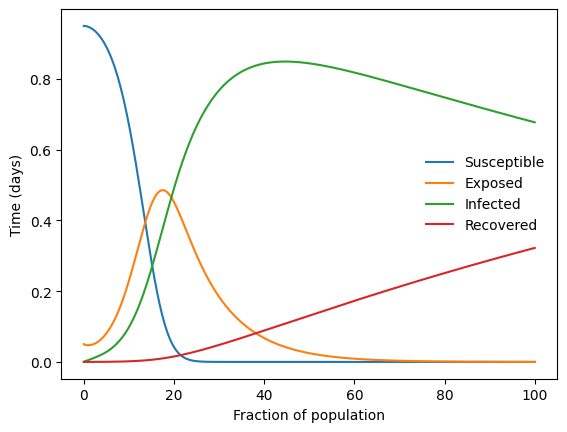

In [4]:
fig, ax = plt.subplots()

for label in seir_labels:
    ax.plot(f_euler_df.iloc[:,0], f_euler_df[label.lower()], label=label) # Plotting each population category on the same ax

ax.set_xlabel("Fraction of population")
ax.set_ylabel("Time (days)")
ax.legend(frameon=False)

plt.show()

### Monte Carlo simulation

In [5]:
sim = mc.System(**shared_parameters, length=length, agent_count=agent_count) # Initialising simulation system
sim.run_sim(MCS=MCS, seir_filename=mc_seir_output, lattice_filename=mc_lattice_output) # Running sim

mc_seir_df = pd.read_csv(mc_seir_output)
mc_lattice_df = pd.read_csv(mc_lattice_output)

### Line plot

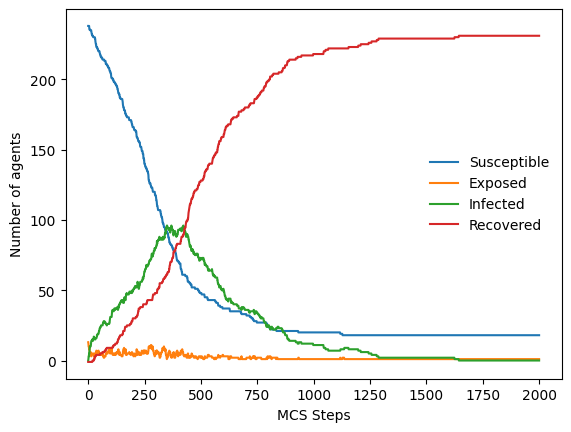

In [6]:
fig, ax = plt.subplots()

for label in seir_labels:
    ax.plot(mc_seir_df.iloc[:,0], mc_seir_df[label.lower()], label=label) # Plotting the same as for the forward Euler data

ax.set_xlabel("MCS Steps")
ax.set_ylabel("Number of agents")
ax.legend(frameon=False)

plt.show()

### Lattice plot

In [ ]:
%matplotlib notebook
# ^ Allows the output to appear in the cell

lattices_1d = mc_lattice_df.iloc[:, 1].to_list() # Extracting the lattices
lattices_2d = []

for l in lattices_1d:
    temp = np.array(l.split(), dtype=int) 
    l_2d = np.reshape(temp, (length, length))
    lattices_2d.append(l_2d) # Taking the lattice strings, turning them into arrays with entry per cell and then reshaping into a grid

fig, ax = plt.subplots(figsize=(7,5), dpi=150) # The dpi is quite high as when it was tested lower, the pixels on the plot didn't all appear the same size.

plot_colors = ['white', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red'] # tab: sets the colours to be the default matplotlib colours, as in the previous 2 plots

cmap = colors.ListedColormap(plot_colors)
norm = colors.NoNorm() # Mapping the colours to the entries. No norm means they'll map in ascending order, e.g. 0 -> white, 1 -> blue etc...

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

image = ax.imshow(lattices_2d[0], cmap=cmap, norm=norm, animated=True, extent=[0, length, length, 0]) # Creating the initial image to update with FuncAnimation

patches = [mpatches.Patch(color=plot_colors[j+1], label=(seir_labels[j])) for j in range(4)] # A custom legend since the current labels would be 1, 2, 3..., this maps each label to a color.
ax.legend(handles=patches, loc=1, bbox_to_anchor=(1.37, 0.6), frameon=False) # Plotting the custom patches

plt.tight_layout()  

def update(frame):
    image.set_data(lattices_2d[frame])
    return [image] # Returning a list for the blitting. This enables the animation to only update parts of the plot that've changed.

animation = FuncAnimation(
    fig,
    update,
    frames=len(lattices_2d),
    interval=50, # The delay between frames
    blit=True # Telling the animation to only update what's changed in the image, not to recreate it each time
)

plt.rcParams['animation.embed_limit'] = 100.0
HTML(animation.to_jshtml()) # Animation takes a minute to load.

<IPython.core.display.Javascript object>